# Electric vehicle with premise: every modelling step in detail


This notebook shows how to use `bw_timex` with a cradle-to-grave case study of an electric vehicle (ev). The case study is simplified, not meant to reflect the complexity of electric mobility but to demonstrate how to use `bw_timex`. 

> **Note:** This is the "premise" version of this notebook that works with ecoinvent and premise data. Specifically, it expects a brightway project with ecoinvent v3.12 (cutoff) and prospective databases for 2020, 2030 and 2040, created from it with [`premise`](https://github.com/polca/premise) (all sectors updated, REMIND-EU SSP2-NDC). If you don't have access to that, please check out the ["standalone" version](../tutorials/2_electric_vehicle_from_scratch.ipynb) of this notebook.


In [1]:
import bw2data as bd

bd.projects.set_current("ei312_REMIND_EU")

## Prospective background databases

The `bw_timex` package itself does not provide any data - specifying prospective and dynamic information is up to the user. In this example, we use data from [ecoinvent v3.12](https://ecoinvent.org/) (cutoff), and create a set of prospective databases with [`premise`](https://github.com/polca/premise), updating all sectors along the SSP2-NDC pathway of the IAM REMIND-EU. We selected this pathway to simply demonstrate some future development in this case study, and many other models and pathways are available. 
In the [premise documentation](https://premise.readthedocs.io/en/latest/) you can find instructions for the creation of prospective background databases. 


In [2]:
db_2020 = bd.Database("ei312_REMIND-EU_SSP2_NDC_2020")
db_2030 = bd.Database("ei312_REMIND-EU_SSP2_NDC_2030")
db_2040 = bd.Database("ei312_REMIND-EU_SSP2_NDC_2040")

## Case study setup


In this study, we consider the following production system for our ev. Purple boxes are foreground, cyan boxes are background (i.e., ecoinvent/premise).

```mermaid
flowchart LR
    glider_production(glider production):::ei-->ev_production
    powertrain_production(powertrain production):::ei-->ev_production
    battery_production(battery production):::ei-->ev_production
    ev_production(ev production):::fg-->driving
    electricity_generation(electricity generation):::ei-->driving
    driving(driving):::fg-->used_ev
    used_ev(used ev):::fg-->glider_eol(glider eol):::ei
    used_ev-->powertrain_eol(powertrain eol):::ei
    used_ev-->battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

### Modeling the production system

Now, we need to build this with brightway. If you are not interested in the modeling details, feel free to skip this section.

For our ev model we make the following assumptions:

In [3]:
ELECTRICITY_CONSUMPTION = 0.2 # kWh/km
MILEAGE = 150_000 # km
LIFETIME = 15 # years

# Overall mass: 1200 kg
MASS_GLIDER = 840 # kg
MASS_POWERTRAIN = 80 # kg
MASS_BATTERY = 280 # kg

First, we create a new foreground database:

In [4]:
if "foreground" in bd.databases:
    del bd.databases["foreground"] # to make sure we create the foreground from scratch
foreground = bd.Database("foreground")
foreground.register()

Now, let's creating the foreground activities:


In [5]:
ev_production = foreground.new_node("ev_production", name="production of an electric vehicle", unit="unit")
ev_production['reference product'] = "electric vehicle"
ev_production.save()

driving = foreground.new_node("driving", name="driving an electric vehicle", unit="transport over an ev lifetime")
driving['reference product'] = "transport"
driving.save()

used_ev = foreground.new_node("used_ev", name="used electric vehicle", unit="unit")
used_ev['reference product'] = "used electric vehicle"
used_ev.save()

We take the actual process data from ecoinvent. However, the ecoinvent processes for the ev part production contain exchanges for the end of life treatment in the production processes already, which we want to separate. So let's fix that first by creating new activities without the eol processes:

In [6]:
# Older versions of this notebook wrote the "without EOL" copies directly into the
# premise databases db_2020/db_2030/db_2040. If you ran one of those versions, those
# leftover copies are still there, and they now share their (name, reference product,
# location) with the copies this notebook creates below in ev_background_<year> - same
# date, different database. bw_timex would then refuse to resolve the resulting
# ambiguity. This cleanup is safe: these nodes were created by this notebook, not premise.
for db in [db_2020, db_2030, db_2040]:
    for code in ["glider_production_without_eol", "powertrain_production_without_eol", "battery_production_without_eol"]:
        try:
            db.get(code=code).delete()
        except Exception:
            pass

# The ecoinvent processes for the ev part production contain exchanges for the end of
# life treatment already, which we want to separate. We create copies without them, and
# put those copies into our own databases - one per point in time - so the premise
# databases stay untouched. bw_timex allows several databases to share a date.
modified_dbs = {}
for db in [db_2020, db_2030, db_2040]:
    year = db.name[-4:]
    modified_name = f"ev_background_{year}"
    if modified_name in bd.databases:
        del bd.databases[modified_name]
    modified_db = bd.Database(modified_name)
    if modified_name not in bd.databases:
        modified_db.register()
    modified_dbs[db.name] = modified_db

    glider_production = db.get(name="glider production, passenger car")
    glider_production_without_eol = glider_production.copy(code="glider_production_without_eol", database=modified_name)
    glider_production_without_eol["name"] = "glider production, passenger car, without EOL"
    # glider_production_without_eol["reference product"] = "glider"
    glider_production_without_eol.save()
    for exc in glider_production_without_eol.exchanges():
        if exc.input["name"] == "market for used glider, passenger car":
            exc.delete()
    
    powertrain_production = db.get(name="powertrain production, for electric passenger car")
    powertrain_production_without_eol = powertrain_production.copy(code="powertrain_production_without_eol", database=modified_name)
    powertrain_production_without_eol["name"] = "powertrain production, for electric passenger car, without EOL"
    # powertrain_production_without_eol["reference product"] = "powertrain"
    powertrain_production_without_eol.save()
    for exc in powertrain_production_without_eol.exchanges():
        if exc.input["name"] == "market for used powertrain from electric passenger car, manual dismantling":
            exc.delete()
    
    battery_production = db.get(name="battery production, Li-ion, LiMn2O4, rechargeable")
    battery_production_without_eol = battery_production.copy(code="battery_production_without_eol", database=modified_name)
    battery_production_without_eol["name"] = "battery production, Li-ion, LiMn2O4, rechargeable, without EOL"
    # battery_production_without_eol["reference product"] = "battery"
    battery_production_without_eol.save()
    # For the battery, some waste treatment is buried in the process "battery cell production, Li-ion, 
    # LiMn2O4" - but not for the whole mass of the battery(?). For simplicity, we just leave it in there.

    modified_db.process()

Now, let's build the exchanges, starting with the ev production:

In [7]:
ev_background_2020 = modified_dbs[db_2020.name]
glider_production = ev_background_2020.get(code="glider_production_without_eol")
powertrain_production = ev_background_2020.get(code="powertrain_production_without_eol")
battery_production = ev_background_2020.get(code="battery_production_without_eol")

ev_production.new_edge(input=ev_production, amount=1, type="production").save()

glider_to_ev = ev_production.new_edge(
    input=glider_production,
    amount=MASS_GLIDER, 
    type="technosphere"
)
powertrain_to_ev = ev_production.new_edge(
    input=powertrain_production, 
    amount=MASS_POWERTRAIN, 
    type="technosphere"
)
battery_to_ev = ev_production.new_edge(
    input=battery_production, 
    amount=MASS_BATTERY, 
    type="technosphere"
)

... the end of life:

In [8]:
glider_eol = db_2020.get(name="treatment of used glider, passenger car, shredding")
powertrain_eol = db_2020.get(name="treatment of used powertrain for electric passenger car, manual dismantling")
battery_eol = db_2020.get(name="market for used Li-ion battery")

used_ev.new_edge(input=used_ev, amount=-1, type="production").save()  # -1 as this gets rid of a used car

used_ev_to_glider_eol = used_ev.new_edge(
    input=glider_eol,
    amount=-MASS_GLIDER,
    type="technosphere",
)
used_ev_to_powertrain_eol = used_ev.new_edge(
    input=powertrain_eol,
    amount=-MASS_POWERTRAIN,
    type="technosphere",
)
used_ev_to_battery_eol = used_ev.new_edge(
    input=battery_eol,
    amount=-MASS_BATTERY,
    type="technosphere",
)

...and, finally, driving:

In [9]:
electricity_production = db_2020.get(name="market group for electricity, low voltage", location="DEU")

driving.new_edge(input=driving, amount=1, type="production").save()

driving_to_used_ev = driving.new_edge(input=used_ev, amount=-1, type="technosphere")
ev_to_driving = driving.new_edge(
    input=ev_production, 
    amount=1, 
    type="technosphere"
)
electricity_to_driving = driving.new_edge(
    input=electricity_production,
    amount=ELECTRICITY_CONSUMPTION * MILEAGE,
    type="technosphere",
)

### Adding temporal information

Now that the production system is modelled, we can add temporal distributions at the exchange level. The temporal information we want to embed in our product system looks somewhat like this:

```mermaid
flowchart LR
    glider_production(glider production):::ei-->|0-2 years prior|ev_production
    powertrain_production(powertrain production):::ei-->|1 year prior|ev_production
    battery_production(battery production):::ei-->|1 year prior|ev_production
    ev_production(ev production):::fg-->|2-3 months prior|driving
    electricity_generation(electricity generation):::ei-->|uniformly distributed <br/> over lifetime|driving
    driving(driving):::fg-->|after ev lifetime|used_ev
    used_ev(used ev):::fg-->|3 months after <br/> ev lifetime|glider_eol(glider eol):::ei
    used_ev-->|3 months after <br/> ev lifetime|powertrain_eol(powertrain eol):::ei
    used_ev-->|3 months after <br/> ev lifetime|battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

To include this temopral information, we use the `TemporalDistribution` class from `bw_temporalis`. For more info, take a look at the [bw_temporalis documentation](https://github.com/brightway-lca/bw_temporalis).

Notably, in addition to the timestamp of the occurence of the process (which is shown in the flowchart above), we also need to specify the amount share of the exchange that happens at that time to fully define a `TemporalDistribution`.


In [10]:
from bw_timex import TemporalDistribution, easy_timedelta_distribution
import numpy as np

td_assembly_and_delivery = TemporalDistribution(
    date=np.array([-3, -2], dtype="timedelta64[M]"), amount=np.array([0.2, 0.8])
)

td_glider_production = TemporalDistribution(
    date=np.array([-2, -1, 0], dtype="timedelta64[Y]"), amount=np.array([0.7, 0.1, 0.2])
)

td_produce_powertrain_and_battery = TemporalDistribution(
    date=np.array([-1], dtype="timedelta64[Y]"), amount=np.array([1])
)

td_use_phase = easy_timedelta_distribution(
    start=0,
    end=LIFETIME,
    resolution="Y",
    steps=(LIFETIME + 1),
    kind="uniform", # you can also do "normal" or "triangular" distributions
)

td_disassemble_used_ev = TemporalDistribution(
    date=np.array([LIFETIME + 1], dtype="timedelta64[Y]"), amount=np.array([1])
)

td_treating_waste = TemporalDistribution(
    date=np.array([3], dtype="timedelta64[M]"), amount=np.array([1])
)

Let's explore what a `TemporalDistribution` looks like:

<Axes: xlabel='Time (Months)', ylabel='Amount'>

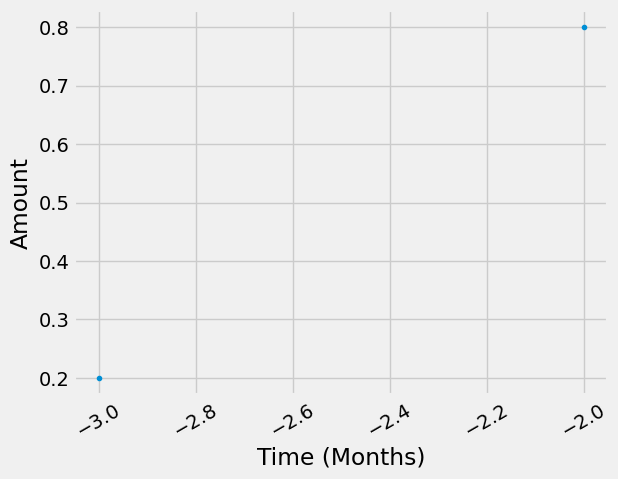

In [11]:
td_assembly_and_delivery.graph(resolution="M")

<Axes: xlabel='Time (Months)', ylabel='Amount'>

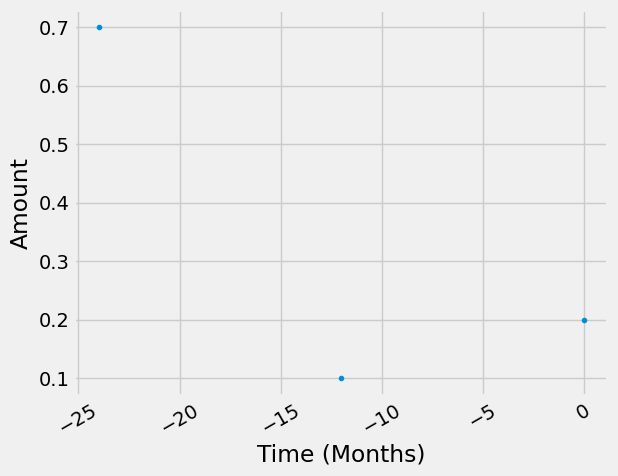

In [12]:
td_glider_production.graph(resolution="M")

Starting from the functional unit in our supply chain graph, the temporal distributions of consecutive edges get "multiplied", or more specifically, convolved. Let's look at an example to clarify this. The assembly and delivery of our ev happens either 2 or 3 months before we can start using it. Each of these occurences of this process demands a glider, which also has a temporal distribution that then gets convolved "back in time". Also pay attention to how the amounts get scaled.

<Axes: xlabel='Time (Months)', ylabel='Amount'>

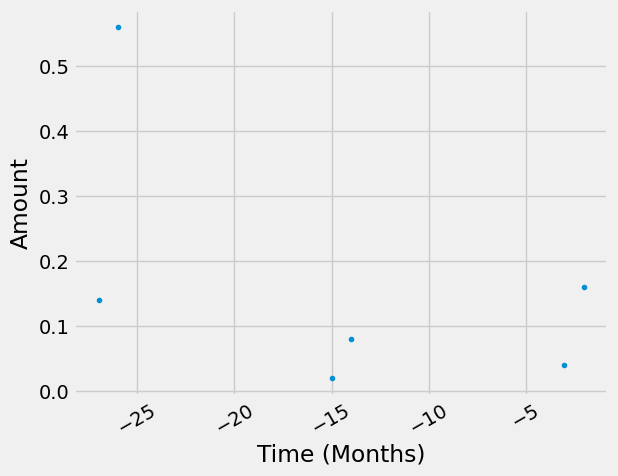

In [13]:
(td_assembly_and_delivery * td_glider_production).graph(resolution="M")

We now add the temporal information to the exchanges of our EV. We add temporal distributions to all (technosphere) exchanges, but you don't have to.


In [14]:
glider_to_ev["temporal_distribution"] = td_glider_production
glider_to_ev.save()

powertrain_to_ev["temporal_distribution"] = td_produce_powertrain_and_battery
powertrain_to_ev.save()

battery_to_ev["temporal_distribution"] = td_produce_powertrain_and_battery
battery_to_ev.save()

ev_to_driving["temporal_distribution"] = td_assembly_and_delivery
ev_to_driving.save()

electricity_to_driving["temporal_distribution"] = td_use_phase
electricity_to_driving.save()

driving_to_used_ev["temporal_distribution"] = td_disassemble_used_ev
driving_to_used_ev.save()

used_ev_to_glider_eol["temporal_distribution"] = td_treating_waste
used_ev_to_glider_eol.save()

used_ev_to_powertrain_eol["temporal_distribution"] = td_treating_waste
used_ev_to_powertrain_eol.save()

used_ev_to_battery_eol["temporal_distribution"] = td_treating_waste
used_ev_to_battery_eol.save()

To make sure our changes to the foreground database are actually saved, we finally need to process the database:

In [15]:
foreground.process()

## LCA using `bw_timex`


As usual, we need to select an impact assessment method:

In [16]:
method = ('ecoinvent-3.12', 'EF v3.1', 'climate change', 'global warming potential (GWP100)')

`bw_timex` also needs to know the representative time of the databases:

In [17]:
from datetime import datetime

database_dates = {
    db_2020.name: datetime.strptime("2020", "%Y"),
    db_2030.name: datetime.strptime("2030", "%Y"),
    db_2040.name: datetime.strptime("2040", "%Y"),
    "ev_background_2020": datetime.strptime("2020", "%Y"),
    "ev_background_2030": datetime.strptime("2030", "%Y"),
    "ev_background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
}

Now, we can instantiate a `TimexLCA`. It's structure is similar to a normal `bw2calc.LCA`, but with the additional argument `database_dates`.

Not sure about the required inputs? Check the documentation using `?`. All our classes and methods have docstrings!

In [18]:
from bw_timex import TimexLCA
TimexLCA?

Let's instantiate a `TimexLCA` object for our "driving" activity:

In [19]:
tlca = TimexLCA({driving: 1}, method, database_dates)

2026-08-03 22:00:28.394 | INFO     | bw_timex.timex_lca:__init__:136 - Initializing TimexLCA object...


2026-08-03 22:00:28.394 | INFO     | bw_timex.timex_lca:__init__:157 - Calculating base LCA...


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.90e+13)
  warnings.warn(msg, UmfpackWarning)
2026-08-03 22:00:29.136 | INFO     | bw_timex.timex_lca:__init__:174 - Collecting node infos...


2026-08-03 22:00:29.174 | INFO     | bw_timex.timex_lca:__init__:186 - Loading node metadata from 7 database(s)...


2026-08-03 22:00:29.943 | INFO     | bw_timex.timex_lca:__init__:223 - TimexLCA initialized.


Next, we build a timeline of the exchanges. To do this, we can call the `build_timeline()` method, which does the graph traversal and creates a timeline dataframe from the results. The exchanges (rows of the dataframe) are aggregated to the resolution specified in the argument `temporal_grouping`. There are also many more options to specify the timeline creation and graph traversal process. Here are the most important ones:
- `temporal_grouping`: temporal resolution to which processes will be aggregated,"year" (default), "month", "day" or "hour"
- `interpolation_type`: How the best fitting background database is selected: "linear"(default), "closest"
- `edge_filter_function`: Custom filter function specifying when to stop the graph traversal.
- `cutoff`: stops graph traversal for nodes below this contribution to the static impact score.
- `max_calc`: stops graph traversal if this number of nodes has been traversed

For all these options, we provide sensible default values. Of course you can always just check the docstrings to see all your options and our assumptions for default values. 

So, let's build the timeline. We choose a monthly temporal grouping here because we use that resolution in our temporal distributions.


In [20]:
tlca.build_timeline(temporal_grouping="month", graph_traversal="bfs")

2026-08-03 22:00:29.946 | INFO     | bw_timex.timex_lca:build_timeline:352 - No edge filter function provided. Skipping all edges in background databases.


2026-08-03 22:00:35.353 | INFO     | bw_timex.timex_lca:build_timeline:373 - Creating activity time mapping...


2026-08-03 22:00:35.443 | INFO     | bw_timex.timeline_builder:__init__:112 - Traversing supply chain graph...


2026-08-03 22:00:35.474 | INFO     | bw_timex.timeline_builder:build_timeline:186 - Building timeline...


2026-08-03 22:00:35.545 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:704 - Reference date 2040-08-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2024-05-01,"glider production, passenger car, without EOL",2026-05-01,production of an electric vehicle,588.0,"{'ev_background_2020': 0.567, 'ev_background_2..."
1,2024-06-01,"glider production, passenger car, without EOL",2026-06-01,production of an electric vehicle,588.0,"{'ev_background_2020': 0.558, 'ev_background_2..."
2,2025-05-01,"glider production, passenger car, without EOL",2026-05-01,production of an electric vehicle,84.0,"{'ev_background_2020': 0.467, 'ev_background_2..."
3,2025-05-01,"powertrain production, for electric passenger ...",2026-05-01,production of an electric vehicle,80.0,"{'ev_background_2020': 0.467, 'ev_background_2..."
4,2025-05-01,"battery production, Li-ion, LiMn2O4, rechargea...",2026-05-01,production of an electric vehicle,280.0,"{'ev_background_2020': 0.467, 'ev_background_2..."
5,2025-06-01,"glider production, passenger car, without EOL",2026-06-01,production of an electric vehicle,84.0,"{'ev_background_2020': 0.459, 'ev_background_2..."
6,2025-06-01,"powertrain production, for electric passenger ...",2026-06-01,production of an electric vehicle,80.0,"{'ev_background_2020': 0.459, 'ev_background_2..."
7,2025-06-01,"battery production, Li-ion, LiMn2O4, rechargea...",2026-06-01,production of an electric vehicle,280.0,"{'ev_background_2020': 0.459, 'ev_background_2..."
8,2026-05-01,"glider production, passenger car, without EOL",2026-05-01,production of an electric vehicle,168.0,"{'ev_background_2020': 0.367, 'ev_background_2..."
9,2026-05-01,production of an electric vehicle,2026-08-01,driving an electric vehicle,0.2,None


The temporal market shares in the timeline (right most column above) specify the share of the amount of an exchange to be sourced from the respective database. 
`None` means that the exchange is in the foreground supply chain, and not at the intersection with the background system.  

Next, we calculate the time-explicit LCI. The `TimexLCA.lci()` function takes care of all the relinking, based on the information from the timeline. 

In [21]:
tlca.lci()

2026-08-03 22:00:35.925 | INFO     | bw_timex.timex_lca:lci:523 - Expanding matrices...


2026-08-03 22:00:35.940 | INFO     | bw_timex.timex_lca:lci:542 - Calculating dynamic inventory...


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 4.97e+12)
  warnings.warn(msg, UmfpackWarning)


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 4.97e+12)
  warnings.warn(msg, UmfpackWarning)


Taking a look at the `dynamic_inventory` that was now created, we can see that it is much larger than a standard static inventory: instead of one row per biosphere flow, we now get one row for each biosphere flow at each point in time.

In [22]:
tlca.dynamic_inventory

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 81026 stored elements and shape (76843, 131071)>

The standard, non-dynamic inventory has far fewer rows because the temporal resolution is missing. We can compare the dimensions of the two inventories:

In [23]:
tlca.base_lca.inventory.shape  # (#rows, #cols)

(3341, 43654)

In [24]:
tlca.dynamic_inventory.shape

(76843, 131071)

While under the hood, the dynamic inventory is calculated as a sparse matrix, there is also a more human-friendly version as a pandas DataFrame:

In [25]:
tlca.dynamic_inventory_df

,date,amount,flow,activity
606,2024-05-01,1.972265e+04,267655083917308008,342758637819838465
2221,2024-05-01,5.665390e+03,267655084743585810,342758637819838465
1346,2024-05-01,3.248506e+03,267655084294795269,342758637819838465
269,2024-05-01,3.220865e+03,267655083611123782,342758637819838465
68,2024-05-01,2.278072e+03,267655083426574452,342758637819838465
...,...,...,...,...
78846,2042-11-01,-1.082068e-07,267655084651311170,342758637819838496
79500,2042-11-01,-3.356238e-07,267655084760363100,342758637819838496
75085,2042-11-01,-4.204561e-07,267655084043137053,342758637819838495
75084,2042-11-01,-3.128459e-06,267655084043137053,342758637819838496


If we are only interested in the new overall time-explicit scores and don't care about the timing of the emissions, we can set `build_dynamic_biosphere=False` (default is `True`), which saves time and memory. In that case, you only get the `TimexLCA.inventory`, but not the `TimexLCA.dynamic_inventory`.

In case the timing of emissions is not important, one can directly calculate the LCIA the "standard way" using static characterization methods. Per default, the following calculates the static LCIA score based on the impact method chosen in the very beginning:

In [26]:
tlca.static_lcia()
tlca.static_score  # kg CO2-eq

10744.473494732374

At this point, we can already compare these time-explicit results to the results of an "ordinary", completely static LCA. These already exist within the `TimexLCA` class, originally to set the priorities for the graph traversal:

In [27]:
tlca.base_lca.score

23247.15112358249

## Dynamic Characterization
In addition to the standard static characterization, the time-explicit, dynamic inventory generated by a `TimexLCA` allows for dynamic characterization. Users can provide their own dynamic characterization functions and link them to corresponding biosphere flows (see example on [dynamic characterization](../tutorials/3_dynamic_characterization.ipynb)). 

Alternatively, you can use the functions from our separate (but fully compatible) package [dynamic_characterization](https://dynamic-characterization.readthedocs.io/en/latest/). We provide two different metrics for dynamic LCIA of Climate Change: Radiative forcing [W/m2] and Global Warming Potential (GWP) [kg CO2-eq]. For both of these metrics, we have parameterized dynamic characterization functions for all GHG's that [IPCC AR6](https://www.ipcc.ch/report/ar6/wg1/chapter/chapter-7/) provides data for.

For the dynamic characterization, users can also choose the length of the considered time horizon (`time_horizon`) and whether it is a fixed time horizon (`fixed_time_horizon`). Fixed means that the time horizon for all emissions (no matter when they occur) starts counting at the time of the functional unit, resulting in shorter time horizons for emissions occuring later. If the time horizon is not fixed (this is what conventional impact assessment factors assume), it starts counting from the timing of the emission.


### Radiative forcing


Because we are using real ecoinvent/premise biosphere flows here, `bw_timex` automatically maps the matching parameterized characterization functions (IPCC AR6) to the corresponding flows. So, unlike when working with custom biosphere flows, we don't need to define and pass the `characterization_functions` ourselves and can directly run the dynamic characterization:

In [28]:
tlca.dynamic_lcia(metric="radiative_forcing", fixed_time_horizon=True)

2026-08-03 22:00:48.111 | INFO     | dynamic_characterization.dynamic_characterization:characterize:126 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


,date,amount,flow,activity
0,2024-12-31 05:49:12,-2.087224e-17,267655083766312992,342758637819838466
1,2024-12-31 05:49:12,-5.218035e-18,267655083766312992,342758637819838465
2,2024-12-31 05:49:12,-1.352591e-18,267655084332544077,342758637819838466
3,2024-12-31 05:49:12,-3.381524e-19,267655084332544077,342758637819838465
4,2024-12-31 05:49:12,2.323448e-41,267655084806500426,342758637819838465
...,...,...,...,...
164271,2126-01-01 14:42:00,3.862480e-16,267655084441595931,342758637819838492
164272,2126-01-01 14:42:00,2.367176e-15,267655084861026358,342758637819838492
164273,2126-01-01 14:42:00,5.069502e-15,267655084705837075,342758637819838492
164274,2126-01-01 14:42:00,9.429912e-15,267655084475150457,342758637819838492


The method call returns a dataframe of all the individual emissions at their respective timesteps, but we can also just look at the overall score:

In [29]:
tlca.dynamic_score

np.float64(9.417047753177288e-10)

To visualize the results, we provide simple plotting functions:

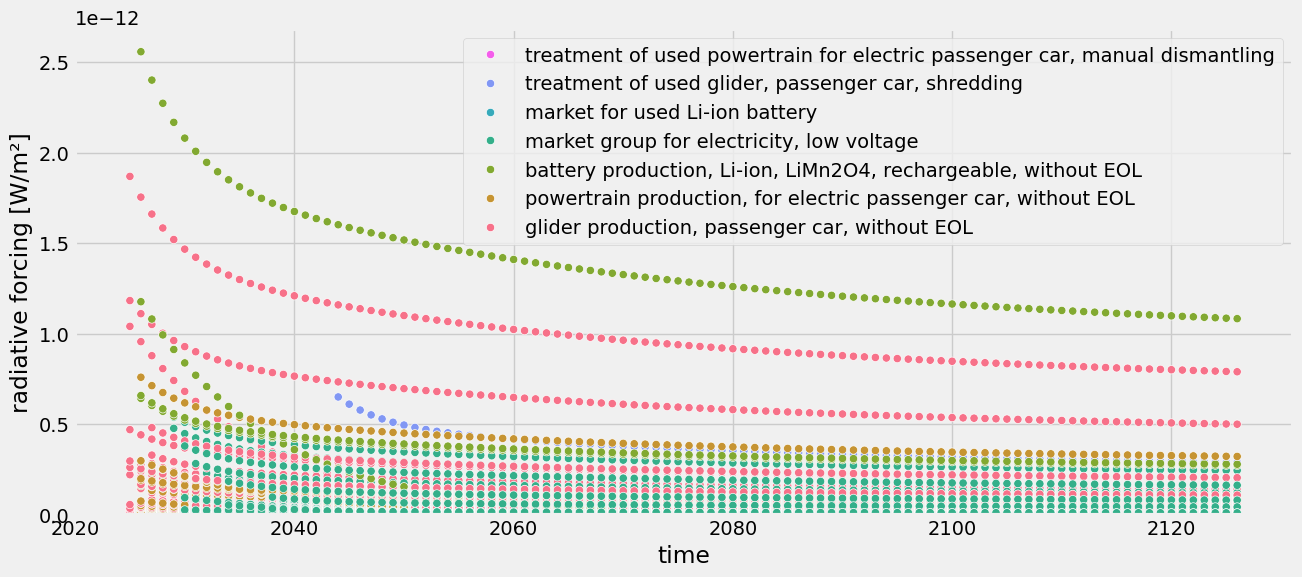

In [30]:
tlca.plot_dynamic_characterized_inventory()

This can be a bit messy, though, because all the individual impacts caused by individual emissions (e.g., CO2, CH4, N2O, ...) appear. Luckily, there is also an option to sum the emissions within each activity:

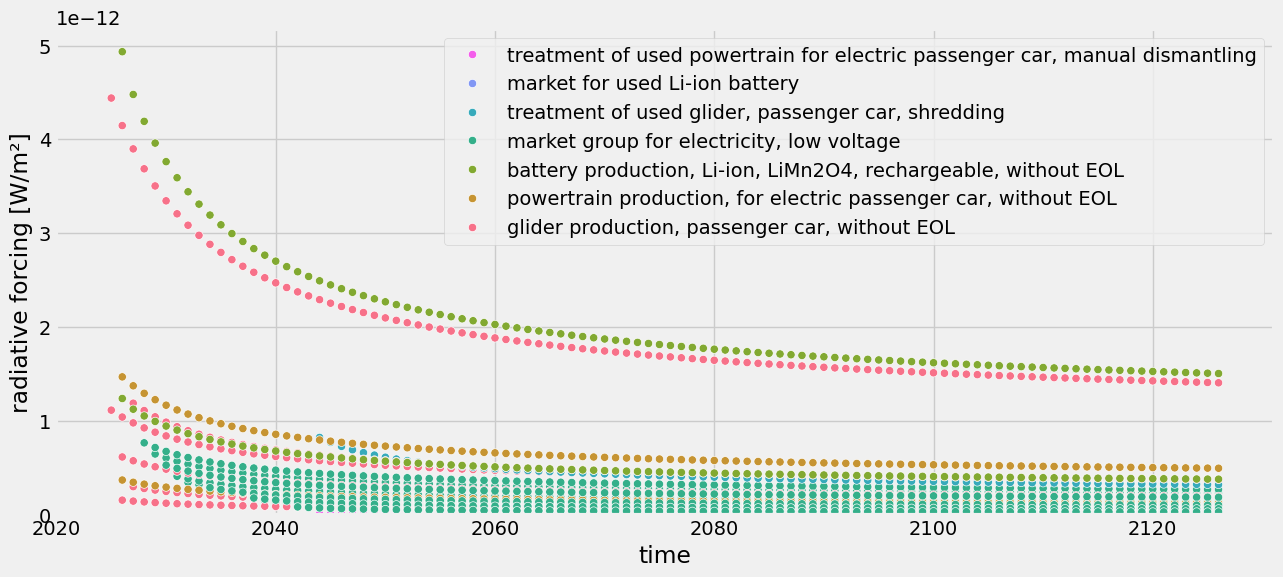

In [31]:
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)

There is also a flag to plot the cumulative score over time:

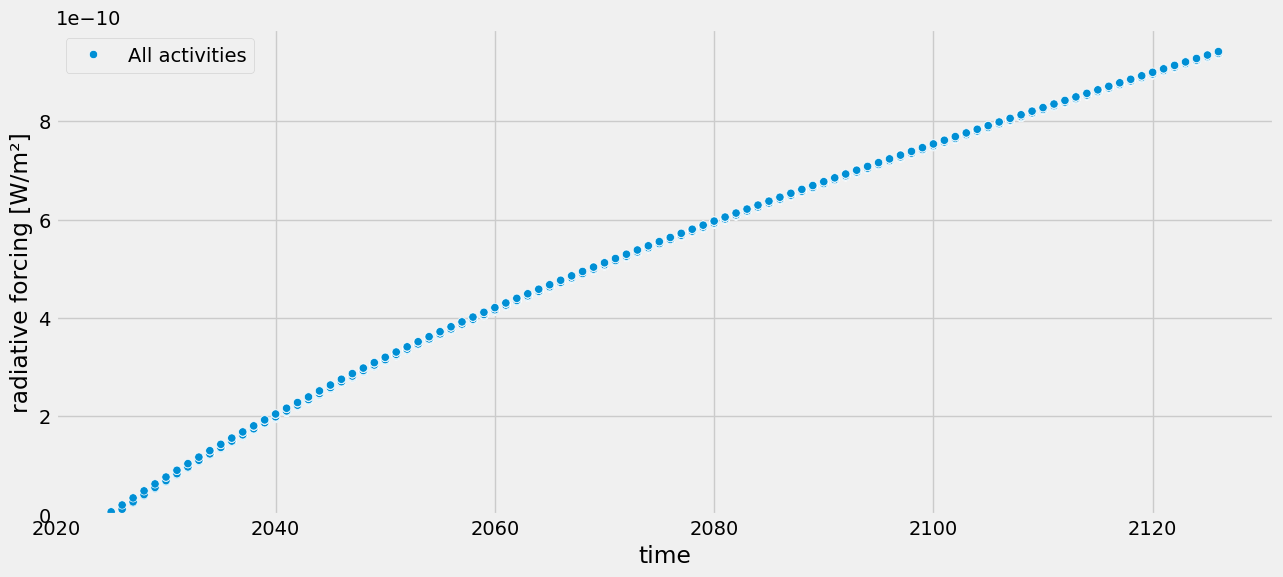

In [32]:
tlca.plot_dynamic_characterized_inventory(sum_activities=True, cumsum=True)

### GWP


Similar options are available for the metric GWP, which compares the radiative forcing of a GHG to that of CO2 over a certain time horizon (commonly 100 years, but it can be set flexibly in `time_horizon`).

In [33]:
tlca.dynamic_lcia(metric="GWP", fixed_time_horizon=False, time_horizon = 100)
tlca.dynamic_score #kg CO2-eq (GWP)

2026-08-03 22:00:50.046 | INFO     | dynamic_characterization.dynamic_characterization:characterize:126 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


np.float64(10655.763775235002)

Plotting the GWP results over time:

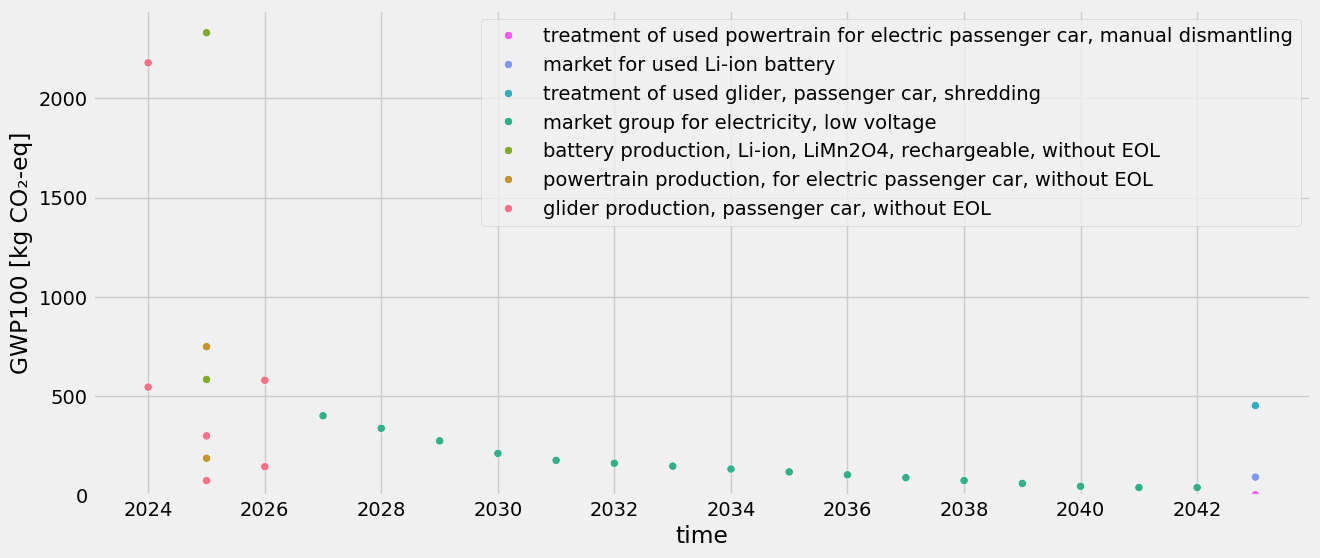

In [34]:
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)

Cumulative:

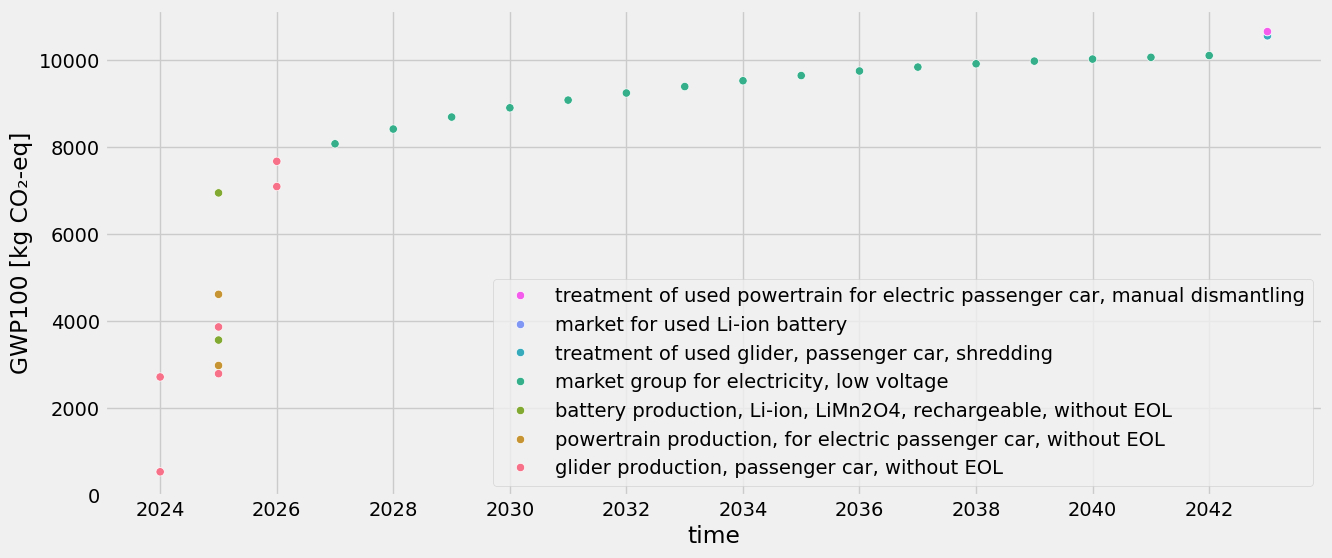

In [35]:
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)

### Comparison of time-explicit results to static results
It's helpful to understand how the time-explicit results differ from those using static assessments. 

We compare the time-explicit results with those of an LCA for the year 2020 and 2040 for the standard GWP100 metric (time horizon=100 and no fixed time horizon). This means we neglect the additional differences of the time-explicit results that would arise from using dynamic LCIA. 

Time-explicit scores:

In [36]:
tlca.dynamic_lcia(metric="GWP", fixed_time_horizon=False, time_horizon=100)
tlca.dynamic_score

2026-08-03 22:00:50.285 | INFO     | dynamic_characterization.dynamic_characterization:characterize:126 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


np.float64(10655.763775235002)

The 2020 (static) score has already been calculated by TimexLCA in the beginning, but we can still access the score:

In [37]:
tlca.base_lca.score

23247.15112358249

However, further down we also want to look at what part of the life cycle has what contribution. To get this info, we need some more calculations:

In [38]:
static_scores = {}
for exc in driving.technosphere():
    if exc.input == ev_production:
        for subexc in exc.input.technosphere():
            tlca.base_lca.lcia(demand={subexc.input.id: exc.amount * subexc.amount * subexc.input.rp_exchange().amount})
            static_scores[subexc.input["name"]] = tlca.base_lca.score
    elif exc.input == used_ev:
        for subexc in exc.input.technosphere():
            tlca.base_lca.lcia(demand={subexc.input.id: exc.amount * subexc.amount * subexc.input.rp_exchange().amount})
            static_scores[subexc.input["name"]] = tlca.base_lca.score
    else:
        tlca.base_lca.lcia(demand={exc.input.id: exc.amount})
        static_scores[exc.input["name"]] = tlca.base_lca.score

/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.90e+13)
  warnings.warn(msg, UmfpackWarning)


Similarly, we calculate the 2040 (prospective) scores by just changing the database the exchanges point to:

In [39]:
import bw2calc as bc

# first create a copy of the system and relink to processes from 2040 database
try:
    prospective_driving = driving.copy(code="prospective_driving", name="driving an electric vehi0cle in 2040")
except:
    foreground.get(code="prospective_driving").delete()
    prospective_driving = driving.copy(code="prospective_driving", name="driving an electric vehicle in 2040")
    

for exc in prospective_driving.technosphere():
    if exc.input == ev_production:
        prospective_ev_production = ev_production.copy(name="production of an electric vehicle in 2040")
        exc.input = prospective_ev_production
        exc.save()
        for subexc in prospective_ev_production.technosphere():
            # The glider/powertrain/battery "without EOL" copies live in our own
            # ev_background_<year> databases, not in the premise database itself -
            # look them up there, matched by their stable code.
            subexc.input = modified_dbs[db_2040.name].get(code=subexc.input["code"])
            subexc.save()
    elif exc.input == used_ev:
        prospective_used_ev = used_ev.copy(name="used electric vehicle in 2040")
        exc.input = prospective_used_ev
        exc.save()
        for subexc in prospective_used_ev.technosphere():
            subexc.input = bd.get_node(
                database=db_2040.name,
                name=subexc.input["name"],
                product=subexc.input["reference product"],
                location=subexc.input["location"],
            )
            subexc.save()
    else:
        exc.input = bd.get_node(
            database=db_2040.name,
            name=exc.input["name"],
            product=exc.input["reference product"],
            location=exc.input["location"],
        )
    exc.save()

prospective_scores = {}
lca = bc.LCA({prospective_driving.key: 1}, method)
lca.lci(factorize=True)
for exc in prospective_driving.technosphere():
    if exc.input["name"] in (prospective_ev_production["name"], prospective_used_ev["name"]):
        for subexc in exc.input.technosphere():
            lca.lcia(demand={subexc.input.id: exc.amount * subexc.amount * subexc.input.rp_exchange().amount})
            prospective_scores[subexc.input["name"]] = lca.score
    else:
        lca.lcia(demand={exc.input.id: exc.amount})
        prospective_scores[exc.input["name"]] = lca.score

22:00:53+0200 [info     ] Changed code to avoid conflict with existing value: {self['code']} to {data['code']}


22:00:53+0200 [info     ] Changed code to avoid conflict with existing value: {self['code']} to {data['code']}


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.38e+13)
  warnings.warn(msg, UmfpackWarning)


Lets compare the overall scores:

In [40]:
print("Static score: ", sum(static_scores.values())) # should be the same as tlca.base_lca.score
print("Prospective score: ", sum(prospective_scores.values()))
print("Time-explicit score: ", tlca.dynamic_score)

Static score:  23247.151123582487
Prospective score:  4927.8914576999105
Time-explicit score:  10655.763775235002


To better understand what's going on, let's plot the scores as a waterfall chart  based on timing of emission. Also, we can look at the "first-level contributions":

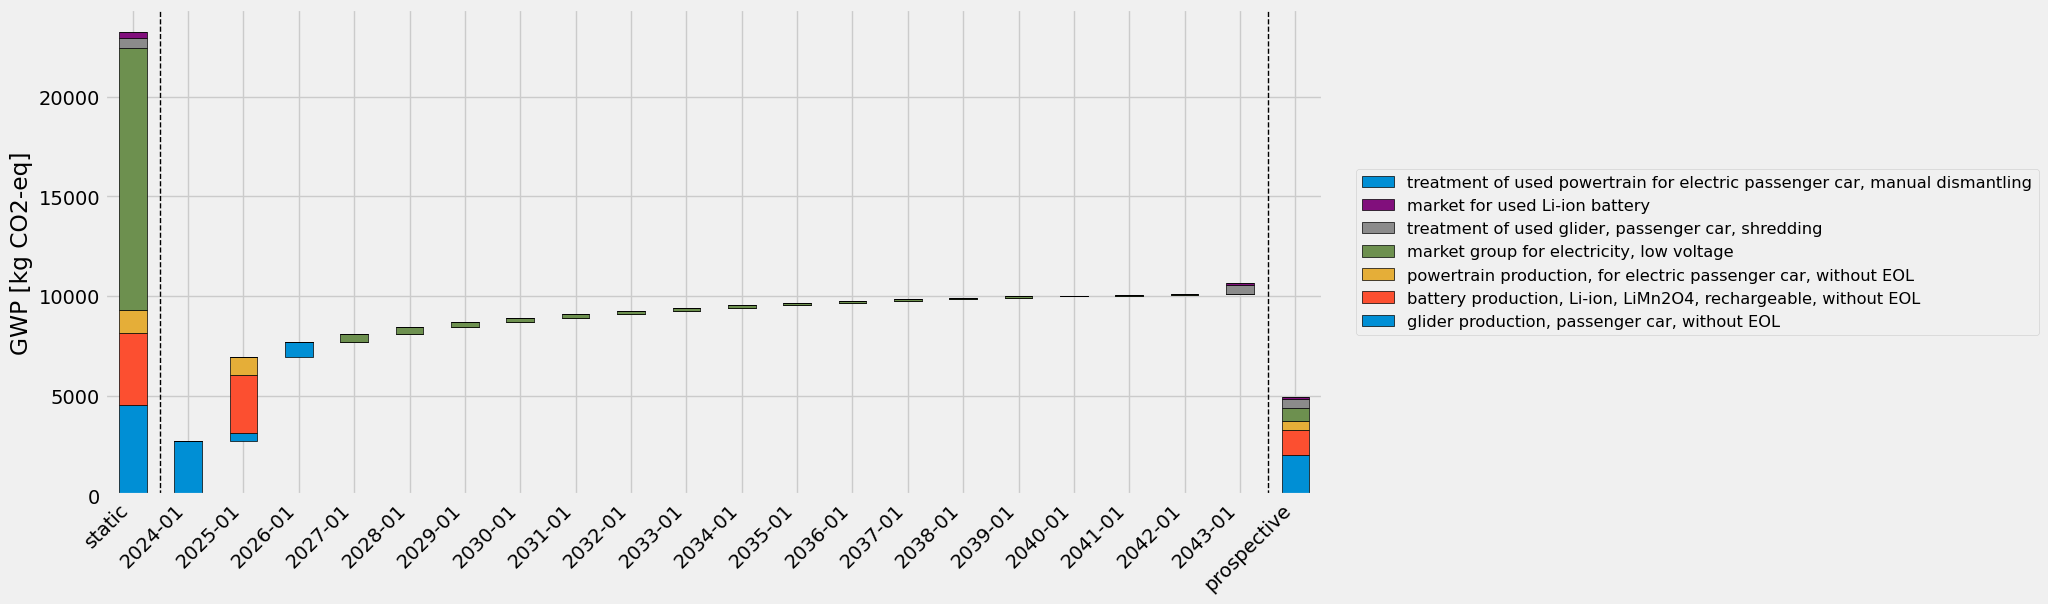

In [41]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall

order_stacked_activities = (
    [ 
        glider_production_without_eol["name"],
        battery_production_without_eol["name"],
        powertrain_production_without_eol["name"],
        electricity_production["name"],
        glider_eol["name"],
        battery_eol["name"],
        powertrain_eol["name"],
    ]
)

plot_characterized_inventory_as_waterfall(
    tlca,
    static_scores=static_scores,
    prospective_scores=prospective_scores,
    order_stacked_activities=order_stacked_activities,
)

One can see that the time-explicit results (in the middle) are somewhere in between the static and the prospective results. This makes sense as at each timestep, the underlying processes are sourced from progressively "cleaner" background databases, reaching a lower impact than if they are only sourced from the current database, but not so low as the prospective results, which are fully sourced from the most decarbonized database. Notably, the electricity consumption in the use-phase, modelled uniformly over the lifetime of the EV, contributes less and less to the score in the later years, since the electricity becomes cleaner in the future databases.